## 01 - Analyse exploratoire et prétraitement (California Housing)
##

In [1]:
import sys
sys.path.append("..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
import os

os.makedirs("../figures", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

 ## 2.2 Présentation du jeu de données

In [2]:
df = pd.read_csv("../data/raw/housing.csv")
print("Shape:", df.shape)
print("\nColonnes disponibles :")
print(df.columns.tolist())
print("\nAperçu :")
display(df.head())

Shape: (20640, 10)

Colonnes disponibles :
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Aperçu :


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2.3 Analyse exploratoire (EDA)


In [3]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[numeric_cols].describe().T
desc['skew'] = df[numeric_cols].skew()
desc['kurtosis'] = df[numeric_cols].kurtosis()
print("Statistiques descriptives – variables numériques brutes :")
display(desc)

Statistiques descriptives – variables numériques brutes :


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100,-0.297801,-1.330152
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500,0.465953,-1.117760
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000,0.060331,-0.800629
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000,4.147343,32.630927
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000,3.459546,21.985575
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000,4.935858,73.553116
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000,3.410438,22.057988
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001,1.646657,4.952524
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000,0.977763,0.327870


 # Visualisations


### Histogrammes

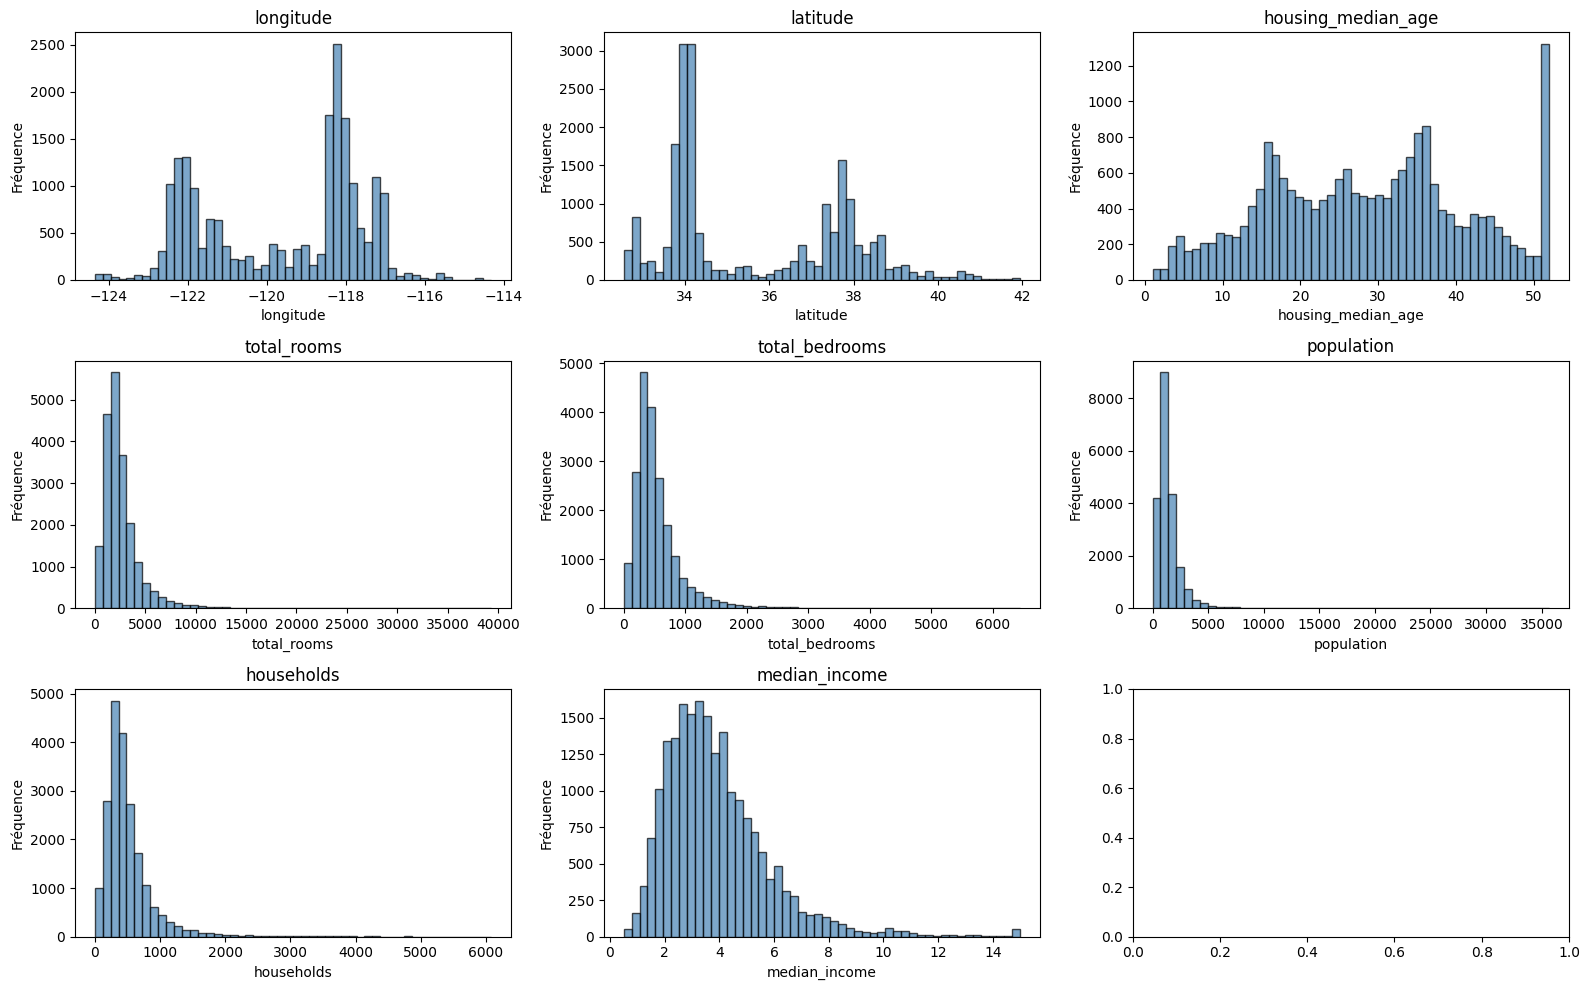

In [4]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
for i, col in enumerate(numeric_cols[:-1]):
    ax = axes[i//3, i%3]
    ax.hist(df[col], bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
plt.tight_layout()
plt.savefig("../figures/hist_features.png", dpi=150)
plt.show()


### Boxplots

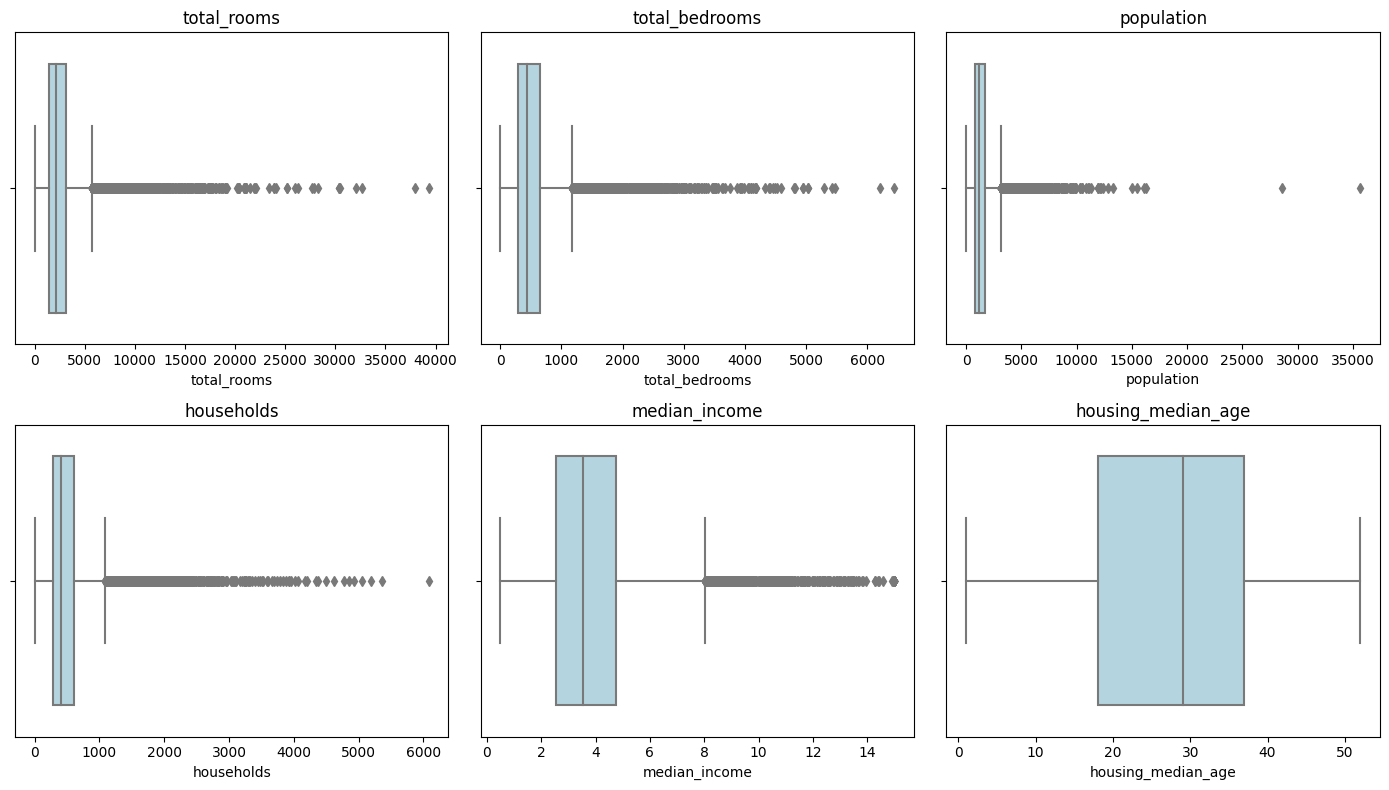

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(['total_rooms', 'total_bedrooms', 'population', 
                         'households', 'median_income', 'housing_median_age']):
    ax = axes[i//3, i%3]
    sns.boxplot(x=df[col], ax=ax, color='lightblue')
    ax.set_title(col)
plt.tight_layout()
plt.savefig("../figures/boxplots_outliers.png", dpi=150)
plt.show()

# Scatter

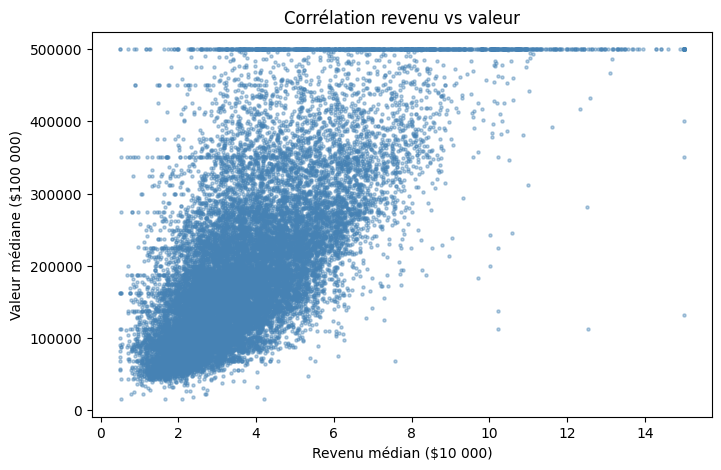

In [6]:
plt.figure(figsize=(8, 5))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.4, s=5, c='steelblue')
plt.xlabel('Revenu médian ($10 000)')
plt.ylabel('Valeur médiane ($100 000)')
plt.title('Corrélation revenu vs valeur')
plt.savefig("../figures/scatter_income_value.png", dpi=150)
plt.show()

### Carte géographique

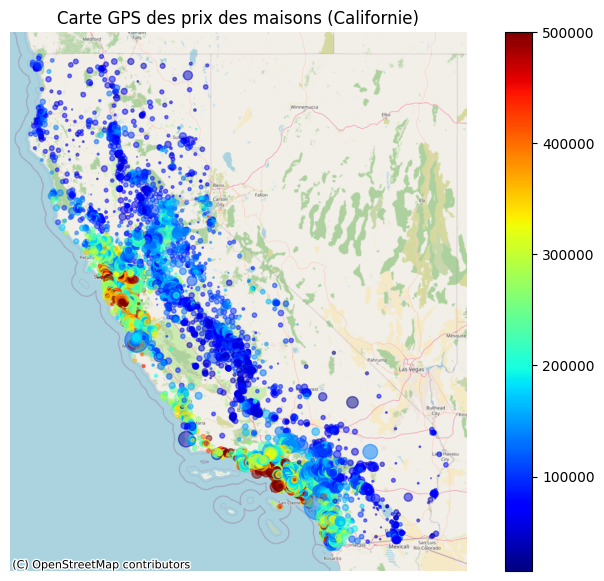

In [7]:
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt

# =========================================
# Conversion DataFrame → GeoDataFrame
# =========================================
gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["longitude"], df["latitude"]),
    crs="EPSG:4326"  # système de coordonnées GPS (latitude/longitude)
)

# =========================================
# Changement de système de projection (CRS)
# IMPORTANT pour l'affichage sur fond de carte
# =========================================
gdf = gdf.to_crs(epsg=3857)  # projection Web Mercator (utilisée par les cartes web)

# =========================================
# Création de la carte
# =========================================
fig, ax = plt.subplots(figsize=(10, 7))

gdf.plot(
    ax=ax,
    alpha=0.5,
    markersize=df["population"] / 100,
    column="median_house_value",
    cmap="jet",
    legend=True
)

# =========================================
# Ajout du fond de carte (OpenStreetMap)
# =========================================
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

# =========================================
# Titre et mise en forme
# =========================================
plt.title("Carte GPS des prix des maisons (Californie)")
plt.axis("off")

# Sauvegarde et affichage
plt.savefig("../figures/geo_price_map_real.png", dpi=150)
plt.show()

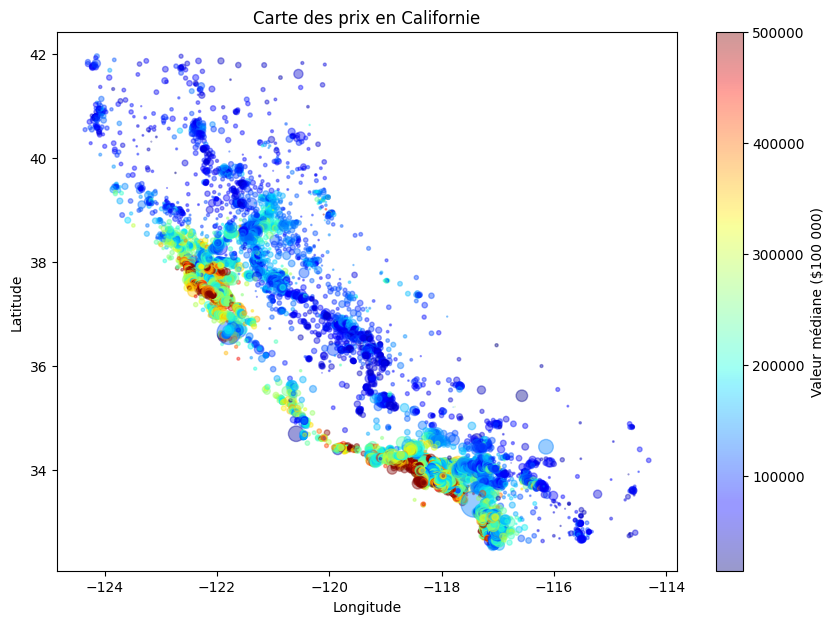

In [8]:
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['longitude'], df['latitude'], 
                 c=df['median_house_value'], 
                 s=df['population']/100, 
                 alpha=0.4, cmap='jet')
plt.colorbar(sc, label='Valeur médiane ($100 000)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Carte des prix en Californie')
plt.savefig("../figures/geo_price_map.png", dpi=150)
plt.show()


# Matrice de corrélation et VIF 

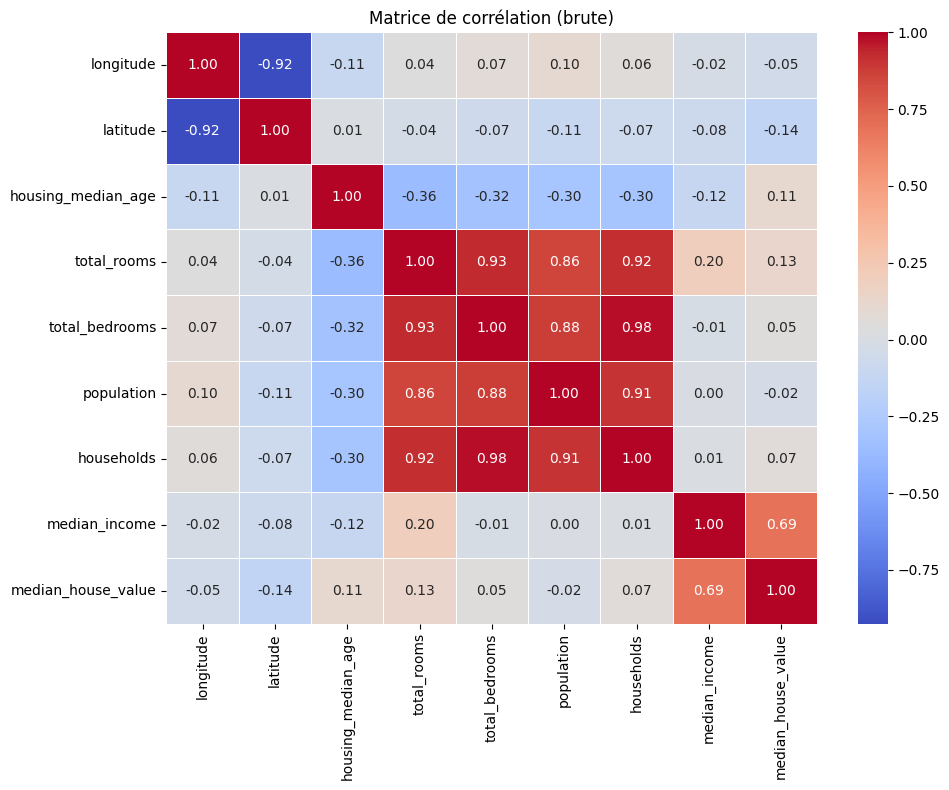

VIF initial (seuil critique > 10) :
              feature         VIF
0           longitude  615.913539
1            latitude  549.460506
2  housing_median_age    7.280281
3         total_rooms   30.511021
4      total_bedrooms   93.969627
5          population   16.431328
6          households   91.444123
7       median_income    8.258816


In [9]:
plt.figure(figsize=(10, 8))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matrice de corrélation (brute)')
plt.tight_layout()
plt.savefig("../figures/correlation_matrix_raw.png", dpi=150)
plt.show()

X_vif = df[numeric_cols].drop('median_house_value', axis=1).dropna()
vif_data = pd.DataFrame()
vif_data['feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
print("VIF initial (seuil critique > 10) :")
print(vif_data)

# Détection des valeurs manquantes

Valeurs manquantes :
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


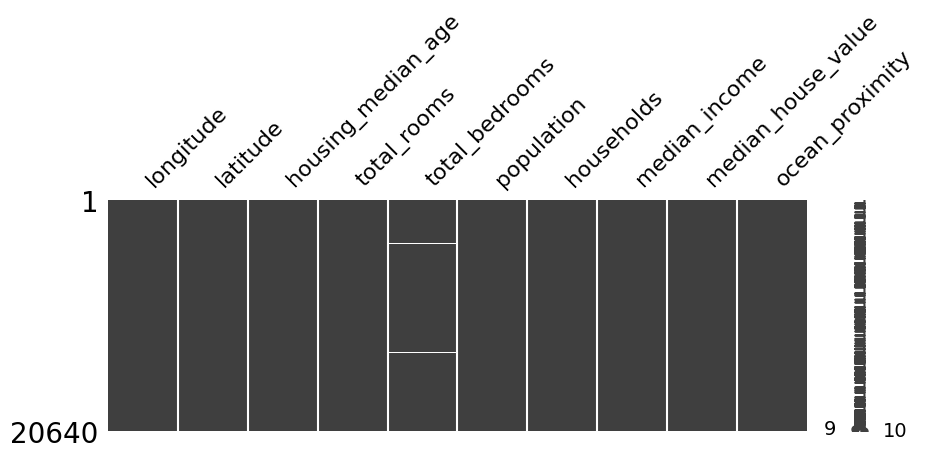

In [10]:
print("Valeurs manquantes :")
print(df.isnull().sum())
msno.matrix(df, figsize=(10, 3))
plt.savefig("../figures/missingno_matrix.png", dpi=150)
plt.show()

## 2.4 Prétraitement

### 2.4.1 Encodage one-hot

In [11]:
print("Modalités de ocean_proximity :")
print(df['ocean_proximity'].value_counts())
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)
df_encoded = df_encoded.astype(float)
print("Shape après encodage :", df_encoded.shape)

Modalités de ocean_proximity :
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64
Shape après encodage : (20640, 13)


### 2.4.2 Partitionnement train/test

In [12]:
target_col = 'median_house_value'
X = df_encoded.drop(columns=[target_col])
y = df_encoded[target_col]

TEST_SIZE = 0.2
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, shuffle=True
)
print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Train : (16512, 12), Test : (4128, 12)


### Vérification de la distribution de la cible dans les deux ensembles :

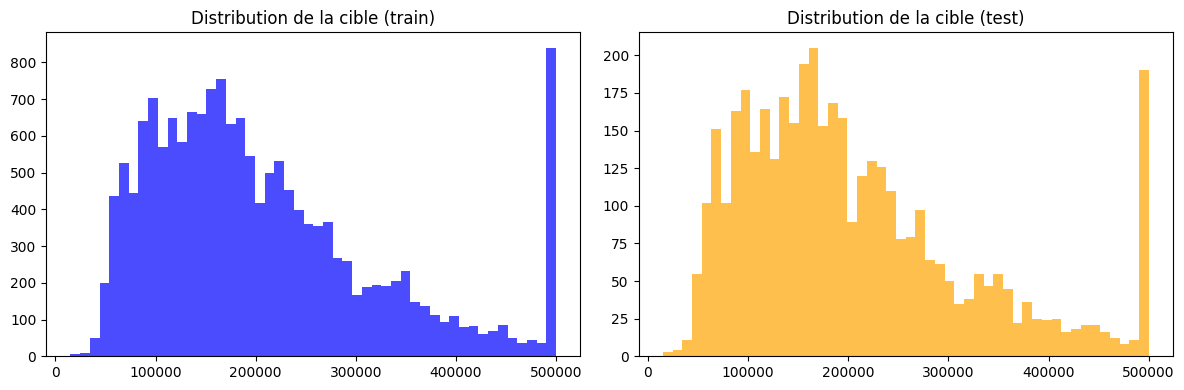

In [13]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(y_train, bins=50, alpha=0.7, color='blue', label='Train')
ax[0].set_title('Distribution de la cible (train)')
ax[1].hist(y_test, bins=50, alpha=0.7, color='orange', label='Test')
ax[1].set_title('Distribution de la cible (test)')
plt.tight_layout()
plt.savefig("../figures/target_distribution_split.png", dpi=150)
plt.show()

 ### 2.4.3 Imputation des valeurs manquantes (après split)



In [14]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = X_train.copy()
X_test_imputed = X_test.copy()

X_train_imputed[['total_bedrooms']] = imputer.fit_transform(X_train[['total_bedrooms']])
X_test_imputed[['total_bedrooms']] = imputer.transform(X_test[['total_bedrooms']])

print("Valeurs manquantes après imputation :")
print(pd.concat([X_train_imputed.isnull().sum().rename('train'),
                 X_test_imputed.isnull().sum().rename('test')], axis=1))


Valeurs manquantes après imputation :
                            train  test
longitude                       0     0
latitude                        0     0
housing_median_age              0     0
total_rooms                     0     0
total_bedrooms                  0     0
population                      0     0
households                      0     0
median_income                   0     0
ocean_proximity_INLAND          0     0
ocean_proximity_ISLAND          0     0
ocean_proximity_NEAR BAY        0     0
ocean_proximity_NEAR OCEAN      0     0


### 2.4.5 Sauvegarde des données finales

In [15]:
X_train_imputed.to_csv("../data/processed/X_train.csv", index=False)
X_test_imputed.to_csv("../data/processed/X_test.csv", index=False)
y_train.to_csv("../data/processed/y_train.csv", index=False)
y_test.to_csv("../data/processed/y_test.csv", index=False)
print("Données sauvegardées dans data/processed/")


Données sauvegardées dans data/processed/


# Analyse du Notebook d'EDA et Prétraitement

Ce notebook présente une analyse exploratoire approfondie (EDA) et le prétraitement des données du jeu de données **California Housing**, une référence en machine learning.

---

## 1. Structure du Notebook

1. **Importation des bibliothèques**
2. **Présentation du jeu de données**
3. **Analyse exploratoire (EDA)**
   - Statistiques descriptives
   - Histogrammes
   - Boxplots
   - Scatter plot (revenu vs valeur)
   - Carte géographique
4. **Matrice de corrélation et VIF**
5. **Détection des valeurs manquantes**
6. **Prétraitement**
   - Encodage one-hot
   - Partitionnement train/test
   - Imputation des valeurs manquantes
   - Sauvegarde des données finales

---

## 2. Analyse des Données

### 2.1 Structure du Dataset

- **20 640 lignes** et **10 colonnes**
- Variables numériques :
  - `longitude` : coordonnées géographiques
  - `latitude` : coordonnées géographiques
  - `housing_median_age` : âge médian des logements
  - `total_rooms` : nombre total de pièces
  - `total_bedrooms` : nombre total de chambres
  - `population` : population du bloc
  - `households` : nombre de foyers
  - `median_income` : revenu médian
  - `median_house_value` : **cible** (valeur médiane des maisons)
- Variable catégorielle :
  - `ocean_proximity` : proximité de l'océan

### 2.2 Statistiques Descriptives Clés

| Variable | Min | Max | Moyenne | Skew |
|----------|-----|-----|---------|------|
| `median_house_value` | 14 999 | 500 001 | 206 856 | 0.98 |
| `median_income` | 0.4999 | 15.0001 | 3.87 | 1.65 |
| `total_rooms` | 2 | 39 320 | 2 636 | 4.15 |

**Observations :**
- Forte asymétrie (**skew élevé**) pour `total_rooms`, `total_bedrooms`, `population`
- `median_house_value` plafonnée à **500 000**
- Valeurs manquantes pour `total_bedrooms` (207 lignes)

---

## 3. Visualisations

### 3.1 Histogrammes
- Distributions asymétriques pour les variables de volume
- Distribution relativement normale pour `median_income` et `housing_median_age`

### 3.2 Boxplots
- Présence de nombreux **outliers** pour les variables de volume
- Indicateurs de valeurs extrêmes à prendre en compte

### 3.3 Corrélation Revenu vs Valeur
- Corrélation positive marquée entre `median_income` et `median_house_value`
- Relation presque linéaire avec un bruit important

### 3.4 Carte Géographique
- Visualisation spatiale des prix en Californie
- Plus forte concentration de valeurs élevées près des côtes (Bay Area, Los Angeles)

---

## 4. Multicolinéarité (VIF)

Les VIF (Variance Inflation Factor) initiaux montrent une **forte multicolinéarité** :

| Variable | VIF |
|----------|-----|
| `longitude` | **615.91** |
| `latitude` | **549.46** |
| `total_bedrooms` | **93.97** |
| `households` | **91.44** |
| `total_rooms` | **30.51** |
| `population` | **16.43** |

**Interprétation :**
- VIF > 10 indique une colinéarité problématique
- Nécessité de réduire la dimensionnalité (PCA, sélection de features, création de ratios)

---

## 5. Prétraitement Effectué

### 5.1 Encodage One-Hot
- Transformation de la variable `ocean_proximity` (5 modalités)
- Création de 4 colonnes binaires (drop_first=True)
- Shape final : **(20640, 13)**

### 5.2 Partitionnement Train/Test
- **80% entraînement** (16 512 lignes)
- **20% test** (4 128 lignes)
- Random seed fixé à 42 pour reproductibilité

### 5.3 Imputation
- Imputation de `total_bedrooms` par la **médiane**
- Appliquée séparément sur train et test (évite le data leakage)

### 5.4 Sauvegarde
- Fichiers sauvegardés dans `data/processed/`
- `X_train.csv`, `X_test.csv`, `y_train.csv`, `y_test.csv`

---


---

**Ce notebook constitue une base solide pour la modélisation prédictive des prix de l'immobilier en Californie.**